In [1]:
import pandas as pd

In [3]:
file_path = r"C:\Users\ganta\Downloads\Q-ledger\TN_Land_Registry_1000_Sample_Records1.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
print("Rows and columns:", df.shape)

Rows and columns: (1000, 19)


In [5]:
df.head()

,Land Record ID,District,Taluk,Village,Survey Number,Sub Division,Owner Name,Owner Mobile Number,Land Area (Acres),Land Type,Irrigation Source,Soil Type,Usage Type,Market Value (INR),Record Status,Village Administrative Officer (VAO),Revenue Inspector,Tahsildar Approval Status,Last Updated Date
0,TN-LAND-0001,Salem,Taluk-C,Village-9,774/4,2,Owner-1,9597186965,8.64,Wet Land,Canal,Alluvial Soil,Commercial,2540205,Pending Verification,VAO-23,RI-21,Approved,02/05/2024
1,TN-LAND-0002,Trichy,Taluk-B,Village-3,536/4,1,Owner-2,9378741146,8.67,Wet Land,River,Black Cotton Soil,Residential,587775,Under Dispute,VAO-43,RI-15,Pending,26/01/2025
2,TN-LAND-0003,Erode,Taluk-C,Village-10,594/3,3,Owner-3,9877512397,4.89,Wet Land,Borewell,Red Soil,Agricultural,1401191,Under Dispute,VAO-46,RI-14,Pending,08/09/2024
3,TN-LAND-0004,Trichy,Taluk-A,Village-19,524/5,2,Owner-4,9234311708,8.98,Dry Land,Tank,Red Soil,Commercial,574358,Active,VAO-32,RI-18,Approved,05/06/2024
4,TN-LAND-0005,Salem,Taluk-C,Village-12,777/4,5,Owner-5,9398640242,2.78,Dry Land,Rain-fed,Sandy Soil,Residential,1783610,Pending Verification,VAO-4,RI-7,Rejected,27/09/2024


In [6]:
print(df.columns.tolist())

['Land Record ID', 'District', 'Taluk', 'Village', 'Survey Number', 'Sub Division', 'Owner Name', 'Owner Mobile Number', 'Land Area (Acres)', 'Land Type', 'Irrigation Source', 'Soil Type', 'Usage Type', 'Market Value (INR)', 'Record Status', 'Village Administrative Officer (VAO)', 'Revenue Inspector', 'Tahsildar Approval Status', 'Last Updated Date']


In [7]:
df.isnull().sum()

Land Record ID                          0
District                                0
Taluk                                   0
Village                                 0
Survey Number                           0
Sub Division                            0
Owner Name                              0
Owner Mobile Number                     0
Land Area (Acres)                       0
Land Type                               0
Irrigation Source                       0
Soil Type                               0
Usage Type                              0
Market Value (INR)                      0
Record Status                           0
Village Administrative Officer (VAO)    0
Revenue Inspector                       0
Tahsildar Approval Status               0
Last Updated Date                       0
dtype: int64

In [8]:
clean_df = df.copy()

print("Original dataset:", df.shape)
print("Working copy:", clean_df.shape)

Original dataset: (1000, 19)
Working copy: (1000, 19)


In [9]:
clean_df = clean_df.drop(columns=["Owner Mobile Number"])

print("Shape after removing mobile numbers:", clean_df.shape)

Shape after removing mobile numbers: (1000, 18)


In [10]:
for column in clean_df.select_dtypes(include="object").columns:
    clean_df[column] = clean_df[column].str.strip()
clean_df = clean_df.rename(columns={
    "Land Record ID": "record_id",
    "District": "district",
    "Taluk": "taluk",
    "Village": "village",
    "Survey Number": "survey_number",
    "Sub Division": "sub_division",
    "Owner Name": "owner_name",
    "Land Area (Acres)": "land_area_acres",
    "Land Type": "land_type",
    "Irrigation Source": "irrigation_source",
    "Soil Type": "soil_type",
    "Usage Type": "usage_type",
    "Market Value (INR)": "market_value_inr",
    "Record Status": "record_status",
    "Village Administrative Officer (VAO)": "vao",
    "Revenue Inspector": "revenue_inspector",
    "Tahsildar Approval Status": "tahsildar_approval_status",
    "Last Updated Date": "last_updated_date"
})

print("Columns renamed successfully!")
print(clean_df.columns.tolist())

Columns renamed successfully!
['record_id', 'district', 'taluk', 'village', 'survey_number', 'sub_division', 'owner_name', 'land_area_acres', 'land_type', 'irrigation_source', 'soil_type', 'usage_type', 'market_value_inr', 'record_status', 'vao', 'revenue_inspector', 'tahsildar_approval_status', 'last_updated_date']


In [11]:
clean_df["land_area_acres"] = pd.to_numeric(
    clean_df["land_area_acres"], errors="coerce"
)

clean_df["market_value_inr"] = pd.to_numeric(
    clean_df["market_value_inr"], errors="coerce"
)

clean_df["last_updated_date"] = pd.to_datetime(
    clean_df["last_updated_date"],
    format="%d/%m/%Y",
    errors="coerce"
)

print(clean_df[[
    "land_area_acres",
    "market_value_inr",
    "last_updated_date"
]].dtypes)

land_area_acres             float64
market_value_inr              int64
last_updated_date    datetime64[ns]
dtype: object


In [12]:
print("Total records:", len(clean_df))
print("Unique record IDs:", clean_df["record_id"].nunique())
print("Duplicate record IDs:", clean_df["record_id"].duplicated().sum())

print("\nMissing values after cleaning:")
print(clean_df.isnull().sum())

print("\nInvalid land areas:", (clean_df["land_area_acres"] <= 0).sum())
print("Negative market values:", (clean_df["market_value_inr"] < 0).sum())

Total records: 1000
Unique record IDs: 1000
Duplicate record IDs: 0

Missing values after cleaning:
record_id                    0
district                     0
taluk                        0
village                      0
survey_number                0
sub_division                 0
owner_name                   0
land_area_acres              0
land_type                    0
irrigation_source            0
soil_type                    0
usage_type                   0
market_value_inr             0
record_status                0
vao                          0
revenue_inspector            0
tahsildar_approval_status    0
last_updated_date            0
dtype: int64

Invalid land areas: 0
Negative market values: 0


In [13]:
output_path = r"C:\Users\ganta\Downloads\Q-ledger\clean_land_records.csv"

clean_df.to_csv(output_path, index=False)

print("Cleaned dataset saved successfully!")
print(output_path)

Cleaned dataset saved successfully!
C:\Users\ganta\Downloads\Q-ledger\clean_land_records.csv


In [14]:
clean_df.head()

,record_id,district,taluk,village,survey_number,sub_division,owner_name,land_area_acres,land_type,irrigation_source,soil_type,usage_type,market_value_inr,record_status,vao,revenue_inspector,tahsildar_approval_status,last_updated_date
0,TN-LAND-0001,Salem,Taluk-C,Village-9,774/4,2,Owner-1,8.64,Wet Land,Canal,Alluvial Soil,Commercial,2540205,Pending Verification,VAO-23,RI-21,Approved,2024-05-02
1,TN-LAND-0002,Trichy,Taluk-B,Village-3,536/4,1,Owner-2,8.67,Wet Land,River,Black Cotton Soil,Residential,587775,Under Dispute,VAO-43,RI-15,Pending,2025-01-26
2,TN-LAND-0003,Erode,Taluk-C,Village-10,594/3,3,Owner-3,4.89,Wet Land,Borewell,Red Soil,Agricultural,1401191,Under Dispute,VAO-46,RI-14,Pending,2024-09-08
3,TN-LAND-0004,Trichy,Taluk-A,Village-19,524/5,2,Owner-4,8.98,Dry Land,Tank,Red Soil,Commercial,574358,Active,VAO-32,RI-18,Approved,2024-06-05
4,TN-LAND-0005,Salem,Taluk-C,Village-12,777/4,5,Owner-5,2.78,Dry Land,Rain-fed,Sandy Soil,Residential,1783610,Pending Verification,VAO-4,RI-7,Rejected,2024-09-27


In [15]:
clean_df.shape

(1000, 18)

In [16]:
import hashlib
import json

In [17]:
protected_columns = [
    "record_id",
    "district",
    "taluk",
    "village",
    "survey_number",
    "sub_division",
    "land_area_acres",
    "land_type",
    "irrigation_source",
    "soil_type",
    "usage_type",
    "market_value_inr",
    "record_status",
    "vao",
    "revenue_inspector",
    "tahsildar_approval_status",
    "last_updated_date"
]

print("Fields included in hashing:", len(protected_columns))

Fields included in hashing: 17


In [18]:
def canonicalize_record(record):
    data = {}

    for column in protected_columns:
        value = record[column]

        if pd.isna(value):
            data[column] = None
        elif column == "last_updated_date":
            data[column] = pd.Timestamp(value).strftime("%Y-%m-%d")
        elif column == "land_area_acres":
            data[column] = float(value)
        elif column == "market_value_inr":
            data[column] = int(value)
        else:
            data[column] = str(value)

    return json.dumps(
        data,
        sort_keys=True,
        separators=(",", ":"),
        ensure_ascii=False
    )

In [19]:
record = clean_df.iloc[0]

record_json = canonicalize_record(record)

record_hash = hashlib.sha256(
    record_json.encode("utf-8")
).hexdigest()

print("Canonical record:")
print(record_json)

print("\nSHA-256 hash:")
print(record_hash)

print("\nHash length:", len(record_hash))

Canonical record:
{"district":"Salem","irrigation_source":"Canal","land_area_acres":8.64,"land_type":"Wet Land","last_updated_date":"2024-05-02","market_value_inr":2540205,"record_id":"TN-LAND-0001","record_status":"Pending Verification","revenue_inspector":"RI-21","soil_type":"Alluvial Soil","sub_division":"2","survey_number":"774/4","tahsildar_approval_status":"Approved","taluk":"Taluk-C","usage_type":"Commercial","vao":"VAO-23","village":"Village-9"}

SHA-256 hash:
be0126ba466fe99a6171b803fd7f463042bc2ee9ec357cc53dcc1e27ad08dbc1

Hash length: 64


In [20]:
clean_df["record_hash"] = clean_df.apply(
    lambda row: hashlib.sha256(
        canonicalize_record(row).encode("utf-8")
    ).hexdigest(),
    axis=1
)

clean_df[["record_id", "record_hash"]].head()

,record_id,record_hash
0,TN-LAND-0001,be0126ba466fe99a6171b803fd7f463042bc2ee9ec357c...
1,TN-LAND-0002,7e0d3b7bdd6b0b218c78b0f5eaf53d57317675da1f8697...
2,TN-LAND-0003,0d5b76697102655835eda6647073e096e863203d59bae6...
3,TN-LAND-0004,78c5437905b68ffa8ea3a1baa2f3bab48a1b6984583411...
4,TN-LAND-0005,ebee53a31115ddaba78142f85d8e2a8fb56171c8256b21...


In [21]:
print(
    "All hashes are 64 characters:",
    clean_df["record_hash"].str.len().eq(64).all()
)

print(
    "Unique record hashes:",
    clean_df["record_hash"].nunique()
)

All hashes are 64 characters: True
Unique record hashes: 1000


In [22]:
hashed_output_path = (
    r"C:\Users\ganta\Downloads\Q-ledger\hashed_land_records.csv"
)

clean_df.to_csv(hashed_output_path, index=False)

print("Hashed dataset saved to:")
print(hashed_output_path)

Hashed dataset saved to:
C:\Users\ganta\Downloads\Q-ledger\hashed_land_records.csv


In [23]:
original_record = clean_df.iloc[0].copy()
tampered_record = original_record.copy()

tampered_record["land_area_acres"] = (
    float(tampered_record["land_area_acres"]) + 1
)

original_hash = hashlib.sha256(
    canonicalize_record(original_record).encode("utf-8")
).hexdigest()

tampered_hash = hashlib.sha256(
    canonicalize_record(tampered_record).encode("utf-8")
).hexdigest()

print("Original hash:", original_hash)
print("Tampered hash:", tampered_hash)
print("Hashes match:", original_hash == tampered_hash)

Original hash: be0126ba466fe99a6171b803fd7f463042bc2ee9ec357cc53dcc1e27ad08dbc1
Tampered hash: cbdd351dfa2f4b906375c833ee9201a3d911e70ef6e60ad864cb8b0476d5312a
Hashes match: False


In [24]:
%pip install -U cryptography

   ---------------------------------------- 0.0/3.8 MB ? eta -:--:--
   ---------- ----------------------------- 1.0/3.8 MB 5.1 MB/s eta 0:00:01
   ------------------- -------------------- 1.8/3.8 MB 4.4 MB/s eta 0:00:01
   --------------------------- ------------ 2.6/3.8 MB 4.2 MB/s eta 0:00:01
   ----------------------------------- ---- 3.4/3.8 MB 4.1 MB/s eta 0:00:01
   ---------------------------------------- 3.8/3.8 MB 3.9 MB/s  0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 46.0.3
    Uninstalling cryptography-46.0.3:
      Successfully uninstalled cryptography-46.0.3
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyopenssl 25.3.0 requires cryptography<47,>=45.0.7, but you have cryptography 50.0.2 which is incompatible.


In [1]:
import cryptography

print("Cryptography version:", cryptography.__version__)

Cryptography version: 50.0.2


In [3]:
import sys
import cryptography

print("Python executable:", sys.executable)
print("Cryptography version:", cryptography.__version__)
print("Cryptography location:", cryptography.__file__)

Python executable: C:\Users\ganta\anaconda3\python.exe
Cryptography version: 50.0.2
Cryptography location: C:\Users\ganta\anaconda3\Lib\site-packages\cryptography\__init__.py


In [4]:
import cryptography.hazmat.primitives.asymmetric as asymmetric

print("Available modules:")
print(dir(asymmetric))

Available modules:
['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'annotations']


In [5]:
import importlib.util

print("ML-DSA module:", importlib.util.find_spec(
    "cryptography.hazmat.primitives.asymmetric.ml_dsa"
))

ML-DSA module: None


In [6]:
try:
    from cryptography.hazmat.primitives.asymmetric.ml_dsa import MLDSA65
    print("ML-DSA is available!")
except Exception as e:
    print(type(e).__name__, str(e))

ModuleNotFoundError No module named 'cryptography.hazmat.primitives.asymmetric.ml_dsa'


In [1]:
import sys
import cryptography

print("Python:", sys.executable)
print("Cryptography:", cryptography.__version__)

from cryptography.hazmat.primitives.asymmetric import ml_dsa

print("ML-DSA module imported successfully!")
print("ML-DSA-65 available:", hasattr(ml_dsa, "MLDSA65"))

Python: C:\Users\ganta\anaconda3\envs\qledger-pqc\python.exe
Cryptography: 50.0.2


ImportError: cannot import name 'ml_dsa' from 'cryptography.hazmat.primitives.asymmetric' (C:\Users\ganta\anaconda3\envs\qledger-pqc\Lib\site-packages\cryptography\hazmat\primitives\asymmetric\__init__.py)

In [2]:
import os
import cryptography.hazmat.primitives.asymmetric as asymmetric

print("Asymmetric package location:")
print(asymmetric.__path__)

print("\nAvailable asymmetric modules:")
print([
    name for name in os.listdir(list(asymmetric.__path__)[0])
    if "dsa" in name.lower() or "ml" in name.lower()
])

Asymmetric package location:
['C:\\Users\\ganta\\anaconda3\\envs\\qledger-pqc\\Lib\\site-packages\\cryptography\\hazmat\\primitives\\asymmetric']

Available asymmetric modules:
['dsa.py', 'mldsa.py', 'mlkem.py']


In [3]:
from cryptography.hazmat.primitives.asymmetric import mldsa

print("ML-DSA module loaded!")

print([
    name for name in dir(mldsa)
    if "MLDSA" in name
])

ML-DSA module loaded!
['MLDSA44PrivateKey', 'MLDSA44PublicKey', 'MLDSA65PrivateKey', 'MLDSA65PublicKey', 'MLDSA87PrivateKey', 'MLDSA87PublicKey', 'MLDSAMuHasher']


In [4]:
from cryptography.hazmat.primitives.asymmetric.mldsa import MLDSA65
from cryptography.exceptions import InvalidSignature

# Generate a temporary key pair
private_key = MLDSA65.generate()
public_key = private_key.public_key()

# Sign a test record
record = b"Q-Ledger test land record"
signature = private_key.sign(record)

# Verify the original record
public_key.verify(signature, record)
print("PASS: Original record verified")

# Check that a modified record is rejected
try:
    public_key.verify(signature, b"Modified Q-Ledger test land record")
    print("FAIL: Modified record was accepted")
except InvalidSignature:
    print("PASS: Modified record rejected")

ImportError: cannot import name 'MLDSA65' from 'cryptography.hazmat.primitives.asymmetric.mldsa' (C:\Users\ganta\anaconda3\envs\qledger-pqc\Lib\site-packages\cryptography\hazmat\primitives\asymmetric\mldsa.py)

In [5]:
from cryptography.hazmat.primitives.asymmetric import mldsa

print("Module file:", mldsa.__file__)
print("Available names:")
print([name for name in dir(mldsa) if not name.startswith("_")])

Module file: C:\Users\ganta\anaconda3\envs\qledger-pqc\Lib\site-packages\cryptography\hazmat\primitives\asymmetric\mldsa.py
Available names:
['Buffer', 'MLDSA44PrivateKey', 'MLDSA44PublicKey', 'MLDSA65PrivateKey', 'MLDSA65PublicKey', 'MLDSA87PrivateKey', 'MLDSA87PublicKey', 'MLDSAMuHasher', 'UnsupportedAlgorithm', 'abc', 'annotations', 'rust_openssl']


In [6]:
from cryptography.hazmat.primitives.asymmetric.mldsa import MLDSA65PrivateKey
from cryptography.exceptions import InvalidSignature

# 1. Generate a temporary post-quantum key pair
private_key = MLDSA65PrivateKey.generate()
public_key = private_key.public_key()

# 2. Create a test land record
record = b"Q-Ledger test land record: LR-001"

# 3. Sign the record
signature = private_key.sign(record)
print("Signature generated successfully!")

# 4. Verify the original record
public_key.verify(record, signature)
print("PASS: Original record signature is valid")

# 5. Try verifying a modified record
modified_record = b"Q-Ledger modified land record: LR-001"

try:
    public_key.verify(modified_record, signature)
    print("FAIL: Modified record was accepted")
except InvalidSignature:
    print("PASS: Modified record signature was rejected")

Signature generated successfully!


InvalidSignature: 

In [7]:
from cryptography.hazmat.primitives.asymmetric.mldsa import MLDSA65PrivateKey
from cryptography.exceptions import InvalidSignature

private_key = MLDSA65PrivateKey.generate()
public_key = private_key.public_key()

record = b"Q-Ledger test land record: LR-001"
signature = private_key.sign(record)

# Verify the original record
public_key.verify(signature, record)
print("PASS: Original record signature is valid")

# Verify a modified record
modified_record = b"Q-Ledger modified land record: LR-001"

try:
    public_key.verify(signature, modified_record)
    print("FAIL: Modified record was accepted")
except InvalidSignature:
    print("PASS: Modified record signature was rejected")

PASS: Original record signature is valid
PASS: Modified record signature was rejected


In [8]:
import hashlib
import pandas as pd
from cryptography.hazmat.primitives.asymmetric.mldsa import MLDSA65PrivateKey
from cryptography.exceptions import InvalidSignature

# Generate a demo key pair
private_key = MLDSA65PrivateKey.generate()
public_key = private_key.public_key()

# Sign each canonicalized land record
signed_df = clean_df.copy()
signatures = []

for _, row in signed_df.iterrows():
    message = canonicalize_record(row).encode("utf-8")
    signature = private_key.sign(message)
    signatures.append(signature.hex())

signed_df["mldsa_signature"] = signatures

print("Records signed:", len(signed_df))
print("Signature column added:", "mldsa_signature" in signed_df.columns)

# Save signatures with the cleaned records
signed_df.to_csv("signed_land_records.csv", index=False)
print("Saved signed_land_records.csv")

ModuleNotFoundError: No module named 'pandas'

In [9]:
%pip install pandas

   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.7 MB 5.0 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/9.7 MB 4.0 MB/s eta 0:00:02
   --------- ------------------------------ 2.4/9.7 MB 3.4 MB/s eta 0:00:03
   -------------- ------------------------- 3.4/9.7 MB 4.0 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.7 MB 3.9 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.7 MB 3.9 MB/s eta 0:00:02
   ----------------------- ---------------- 5.8/9.7 MB 4.0 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.7 MB 3.9 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.7 MB 3.9 MB/s eta 0:00:01
   ---------------------------------- ----- 8.4/9.7 MB 3.9 MB/s eta 0:00:01
   ------------------------------------- -- 9.2/9.7 MB 3.9 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.7 MB 3.9 MB/s eta 0:00:01
   ----------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
import sys
import pandas as pd
import cryptography

print("Python:", sys.executable)
print("Pandas:", pd.__version__)
print("Cryptography:", cryptography.__version__)

from cryptography.hazmat.primitives.asymmetric.mldsa import MLDSA65PrivateKey
from cryptography.exceptions import InvalidSignature

print("PASS: Required packages are available")

Python: C:\Users\ganta\anaconda3\envs\qledger-pqc\python.exe
Pandas: 3.0.6
Cryptography: 50.0.2
PASS: Required packages are available


In [2]:

from cryptography.hazmat.primitives.asymmetric.mldsa import MLDSA65PrivateKey
from cryptography.exceptions import InvalidSignature
import pandas as pd

# Generate a post-quantum digital-signature key pair
private_key = MLDSA65PrivateKey.generate()
public_key = private_key.public_key()

# Sign every cleaned land record
signed_df = clean_df.copy()
signatures = []

for _, row in signed_df.iterrows():
    message = canonicalize_record(row).encode("utf-8")
    signature = private_key.sign(message)
    signatures.append(signature.hex())

signed_df["mldsa_signature"] = signatures

# Save the signed records
signed_df.to_csv("signed_land_records.csv", index=False)

print("Records signed:", len(signed_df))
print("Signature column added:", "mldsa_signature" in signed_df.columns)
print("Saved: signed_land_records.csv")


NameError: name 'clean_df' is not defined

In [3]:

import pandas as pd

file_path = r"C:\Users\ganta\Downloads\Q-ledger\TN_Land_Registry_1000_Sample_Records1.csv"

df = pd.read_csv(file_path)

# Remove the mobile number to avoid exposing personal information
clean_df = df.drop(columns=["Owner Mobile Number"], errors="ignore").copy()

# Standardize column names
clean_df.columns = clean_df.columns.str.strip().str.lower()
clean_df.columns = (
    clean_df.columns
    .str.replace(r"[^\w]+", "_", regex=True)
    .str.strip("_")
)

# Clean text values
for col in clean_df.select_dtypes(include="object").columns:
    clean_df[col] = clean_df[col].str.strip()

print("Dataset loaded successfully!")
print("Rows:", len(clean_df))
print("Columns:", len(clean_df.columns))
print(clean_df.columns.tolist())


Dataset loaded successfully!
Rows: 1000
Columns: 18
['land_record_id', 'district', 'taluk', 'village', 'survey_number', 'sub_division', 'owner_name', 'land_area_acres', 'land_type', 'irrigation_source', 'soil_type', 'usage_type', 'market_value_inr', 'record_status', 'village_administrative_officer_vao', 'revenue_inspector', 'tahsildar_approval_status', 'last_updated_date']


C:\Users\ganta\AppData\Local\Temp\ipykernel_2404\2669966171.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in clean_df.select_dtypes(include="object").columns:


In [4]:

import json
import pandas as pd

# Exclude the owner's name from the signed payload for this demo
protected_columns = [
    col for col in clean_df.columns
    if col != "owner_name"
]

def canonicalize_record(record):
    data = {}

    for col in protected_columns:
        value = record[col]

        if pd.isna(value):
            data[col] = None
        elif isinstance(value, pd.Timestamp):
            data[col] = value.strftime("%Y-%m-%d")
        else:
            data[col] = value.item() if hasattr(value, "item") else value

    return json.dumps(
        data,
        sort_keys=True,
        separators=(",", ":"),
        ensure_ascii=False
    )

print("Canonicalization function ready.")
print("Protected fields:", len(protected_columns))


Canonicalization function ready.
Protected fields: 17


In [5]:

from cryptography.hazmat.primitives.asymmetric.mldsa import MLDSA65PrivateKey

# Generate a post-quantum signature key pair
private_key = MLDSA65PrivateKey.generate()
public_key = private_key.public_key()

signed_df = clean_df.copy()
signatures = []

for _, row in signed_df.iterrows():
    message = canonicalize_record(row).encode("utf-8")
    signatures.append(private_key.sign(message).hex())

signed_df["mldsa_signature"] = signatures
signed_df.to_csv("signed_land_records.csv", index=False)

print("Records signed:", len(signed_df))
print("Saved: signed_land_records.csv")


Records signed: 1000
Saved: signed_land_records.csv


In [6]:

from cryptography.exceptions import InvalidSignature

row = signed_df.iloc[0]
message = canonicalize_record(row).encode("utf-8")
signature = bytes.fromhex(row["mldsa_signature"])

try:
    public_key.verify(signature, message)
    print("PASS: Original land record signature is valid")
except InvalidSignature:
    print("FAIL: Signature verification failed")


PASS: Original land record signature is valid


In [7]:

tampered_record = row.copy()
tampered_record["land_area_acres"] = (
    float(tampered_record["land_area_acres"]) + 10
)

tampered_message = canonicalize_record(tampered_record).encode("utf-8")

try:
    public_key.verify(signature, tampered_message)
    print("FAIL: Tampered record was accepted")
except InvalidSignature:
    print("PASS: Tampered record was rejected")


PASS: Tampered record was rejected


In [8]:

import hashlib
import json

ledger = []
previous_hash = "GENESIS"

for _, row in signed_df.iterrows():
    record_data = canonicalize_record(row)

    entry = {
        "record_id": str(row["land_record_id"]),
        "record_hash": hashlib.sha256(
            record_data.encode("utf-8")
        ).hexdigest(),
        "previous_hash": previous_hash
    }

    # Hash this ledger entry, including its link to the prior entry
    entry_payload = json.dumps(
        entry, sort_keys=True, separators=(",", ":")
    )
    entry["block_hash"] = hashlib.sha256(
        entry_payload.encode("utf-8")
    ).hexdigest()

    ledger.append(entry)
    previous_hash = entry["block_hash"]

print("Ledger entries:", len(ledger))
print("First entry:", ledger[0])
print("Last entry hash:", ledger[-1]["block_hash"])


Ledger entries: 1000
First entry: {'record_id': 'TN-LAND-0001', 'record_hash': '83c1a78f9ab91d6790abb61285d789edeec0de1b321e297eff7a94cd4620a1a2', 'previous_hash': 'GENESIS', 'block_hash': '6b0508f66054518edc01c6ca50f74c0e5360121aa1256d661481bde3e369cef7'}
Last entry hash: 50c9314060bf9de4df623c382a234cdc7fcb78155f5ecc39407bcf56b95c6d1e


In [9]:

def verify_ledger(chain):
    expected_previous_hash = "GENESIS"

    for entry in chain:
        if entry["previous_hash"] != expected_previous_hash:
            return False

        payload = {
            "record_id": entry["record_id"],
            "record_hash": entry["record_hash"],
            "previous_hash": entry["previous_hash"]
        }

        encoded = json.dumps(
            payload, sort_keys=True, separators=(",", ":")
        )
        calculated_hash = hashlib.sha256(
            encoded.encode("utf-8")
        ).hexdigest()

        if calculated_hash != entry["block_hash"]:
            return False

        expected_previous_hash = entry["block_hash"]

    return True

print("Ledger valid:", verify_ledger(ledger))


Ledger valid: True


In [11]:

test_ledger = [entry.copy() for entry in ledger]

test_ledger[0]["record_hash"] = "tampered_hash"

print("Ledger valid after tampering:", verify_ledger(test_ledger))

import json
import pandas as pd

# Save the hash-linked ledger
ledger_df = pd.DataFrame(ledger)
ledger_df.to_csv("qledger_hash_chain.csv", index=False)

# Save a readable JSON copy
with open("qledger_hash_chain.json", "w", encoding="utf-8") as f:
    json.dump(ledger, f, indent=2)

# Verify the original chain
chain_valid = verify_ledger(ledger)

# Verify every record's digital signature
signature_results = []

for _, row in signed_df.iterrows():
    message = canonicalize_record(row).encode("utf-8")
    signature = bytes.fromhex(row["mldsa_signature"])

    try:
        public_key.verify(signature, message)
        signature_results.append(True)
    except InvalidSignature:
        signature_results.append(False)

print("Ledger entries:", len(ledger))
print("Hash chain valid:", chain_valid)
print("Valid signatures:", sum(signature_results))
print("Invalid signatures:", len(signature_results) - sum(signature_results))
print("Saved: qledger_hash_chain.csv")
print("Saved: qledger_hash_chain.json")


Ledger valid after tampering: False
Ledger entries: 1000
Hash chain valid: True
Valid signatures: 1000
Invalid signatures: 0
Saved: qledger_hash_chain.csv
Saved: qledger_hash_chain.json


In [12]:

summary = {
    "project": "Q-Ledger",
    "dataset_records": len(signed_df),
    "signature_algorithm": "ML-DSA-65",
    "hash_algorithm": "SHA-256",
    "valid_signatures": sum(signature_results),
    "invalid_signatures": len(signature_results) - sum(signature_results),
    "hash_chain_valid": verify_ledger(ledger),
    "tamper_detection_test": "Passed"
}

with open("qledger_verification_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print("Saved: qledger_verification_summary.json")


{
  "project": "Q-Ledger",
  "dataset_records": 1000,
  "signature_algorithm": "ML-DSA-65",
  "hash_algorithm": "SHA-256",
  "valid_signatures": 1000,
  "invalid_signatures": 0,
  "hash_chain_valid": true,
  "tamper_detection_test": "Passed"
}
Saved: qledger_verification_summary.json


In [13]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\ganta
['.anaconda', '.android', '.antigravity-ide', '.arduinoIDE', '.cache', '.conda', '.continuum', '.emulator_console_auth_token', '.gemini', '.gitconfig', '.gradle', '.ipynb_checkpoints', '.ipython', '.jupyter', '.local', '.matplotlib', '.ollama', '.pg0', '.redhat', '.streamlit', '.templateengine', '.viminfo', '.virtual_documents', '.vscode', '.vscode-shared', '24jr1a0508DBSCAN.ipynb', '24jr1a0508decisiontree.ipynb', '24jr1a0508KMeans.ipynb', '24jr1a0508randomforest.ipynb', '24jr1a0508svm.ipynb', '24jr1a0509(Assignment1).ipynb', '24jr1a0509.ipynb', '24jr1a0509_chaitraDeepikaGhanta_Assignment.ipynb', '24jr1a0509_chaitraDeepikaGhanta_Assignment1.ipynb', '24jr1a0509_ChaitraDeepikaGhanta_Assignment2.ipynb', '24jr1a0509_ChaitraDeepikaGhanta_Assignment3.ipynb', '24jr1a0509_ChaitraDeepikaGhanta_Assignment4.ipynb', '24jr1a0509_ChaitraDeepika_DBSCAN.ipynb', '24jr1a0509_ChaitraDeepika_decisiontree.ipynb', '24jr1a0509_ChaitraDeepika_KMeans.ipynb', '24jr1a0509_ChaitraDeepika_randomfore

In [14]:

import matplotlib.pyplot as plt

# Verification overview
labels = ["Valid signatures", "Invalid signatures"]
values = [
    sum(signature_results),
    len(signature_results) - sum(signature_results)
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Signature verification chart
axes[0].bar(labels, values)
axes[0].set_title("ML-DSA-65 Signature Verification")
axes[0].set_ylabel("Number of records")
axes[0].tick_params(axis="x", rotation=15)

# Ledger status chart
axes[1].bar(
    ["Original ledger", "Tampered ledger"],
    [int(verify_ledger(ledger)), 0]
)
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(["Invalid", "Valid"])
axes[1].set_title("Hash-Chain Integrity Check")

plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'matplotlib'

In [15]:
%pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.3 MB 5.0 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/9.3 MB 4.4 MB/s eta 0:00:02
   ----------- ---------------------------- 2.6/9.3 MB 4.2 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.3 MB 4.1 MB/s eta 0:00:02
   ------------------- -------------------- 4.5/9.3 MB 4.1 MB/s eta 0:00:02
   ---------------------- ----------------- 5.2/9.3 MB 4.0 MB/s eta 0:00:02
   ------------------------- -------------- 6.0/9.3 MB 3.9 MB/s eta 0:00:01
   ----------------------------- ---------- 6.8/9.3 MB 4.0 MB/s eta 0:00:01
   -------------------------------- ------- 7.6/9.3 MB 3.9 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.3 MB 3.9 MB/s eta 0:00:01
   ---------------------------------------  9.2/9.3 MB 3.9 MB/s eta 0:00:01
   ----------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [16]:
import matplotlib.pyplot as plt

print("Matplotlib version:", plt.matplotlib.__version__)
print("PASS: Visualization library is ready")

Matplotlib version: 3.11.2
PASS: Visualization library is ready


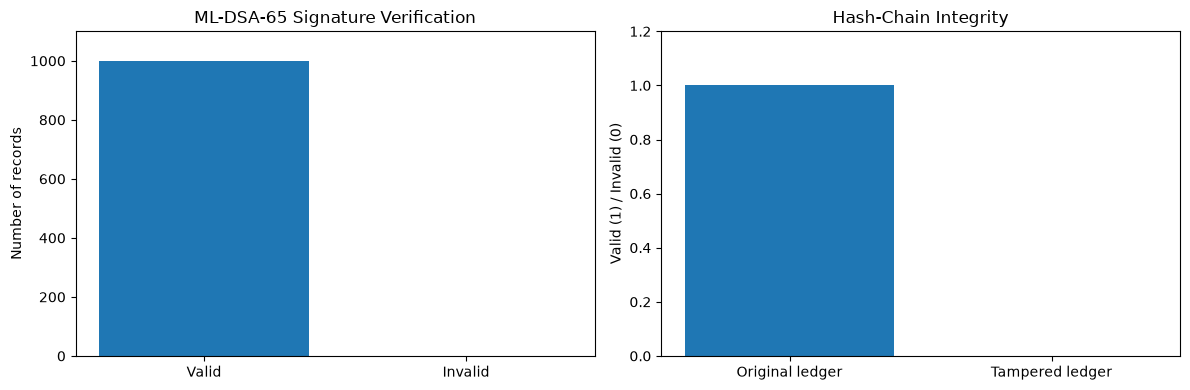

Signature verification: 1000 valid, 0 invalid
Original ledger valid: True
Tampered ledger valid: False


In [17]:

import matplotlib.pyplot as plt

valid_count = sum(signature_results)
invalid_count = len(signature_results) - valid_count

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Chart 1: Digital signature verification
axes[0].bar(
    ["Valid", "Invalid"],
    [valid_count, invalid_count]
)
axes[0].set_title("ML-DSA-65 Signature Verification")
axes[0].set_ylabel("Number of records")
axes[0].set_ylim(0, max(1, len(signature_results)) * 1.1)

# Chart 2: Hash-chain verification
original_valid = verify_ledger(ledger)
tampered_valid = False  # Your earlier tampering test returned False

axes[1].bar(
    ["Original ledger", "Tampered ledger"],
    [int(original_valid), int(tampered_valid)]
)
axes[1].set_title("Hash-Chain Integrity")
axes[1].set_ylabel("Valid (1) / Invalid (0)")
axes[1].set_ylim(0, 1.2)

plt.tight_layout()
plt.show()

print("Signature verification:", valid_count, "valid,", invalid_count, "invalid")
print("Original ledger valid:", original_valid)
print("Tampered ledger valid:", tampered_valid)


In [18]:

from pathlib import Path

chart_path = Path(r"C:\Users\ganta\Downloads\Q-ledger\qledger_verification_chart.png")
chart_path.parent.mkdir(parents=True, exist_ok=True)

fig.savefig(chart_path, dpi=200, bbox_inches="tight")
print("Chart saved to:", chart_path)


Chart saved to: C:\Users\ganta\Downloads\Q-ledger\qledger_verification_chart.png


In [19]:

import ipywidgets as widgets
from IPython.display import display, clear_output
from cryptography.exceptions import InvalidSignature

record_selector = widgets.IntSlider(
    value=0,
    min=0,
    max=len(signed_df) - 1,
    step=1,
    description="Record index:",
    style={"description_width": "initial"},
    continuous_update=False
)

verify_button = widgets.Button(
    description="Verify Record",
    button_style="success"
)

output = widgets.Output()

def verify_selected_record(_):
    with output:
        clear_output(wait=True)

        row = signed_df.iloc[record_selector.value]
        message = canonicalize_record(row).encode("utf-8")
        signature = bytes.fromhex(row["mldsa_signature"])

        try:
            public_key.verify(signature, message)
            print("VALID: Original record signature verified.")
        except InvalidSignature:
            print("INVALID: Original record signature rejected.")
            return

        tampered_row = row.copy()

        # Change one protected field for the demonstration
        area = pd.to_numeric(
            pd.Series([tampered_row["land_area_acres"]]),
            errors="coerce"
        ).iloc[0]

        if pd.isna(area):
            tampered_row["land_area_acres"] = "tampered"
        else:
            tampered_row["land_area_acres"] = float(area) + 10

        changed_message = canonicalize_record(tampered_row).encode("utf-8")

        try:
            public_key.verify(signature, changed_message)
            print("WARNING: Modified record was accepted.")
        except InvalidSignature:
            print("TAMPERING DETECTED: Modified record signature rejected.")

        print("Record index:", record_selector.value)
        print("Record ID:", row["land_record_id"])

verify_button.on_click(verify_selected_record)

display(record_selector, verify_button, output)


ModuleNotFoundError: No module named 'ipywidgets'

In [20]:
%pip install ipywidgets

   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   -------------- ------------------------- 0.8/2.2 MB 4.2 MB/s eta 0:00:01
   -------------------------------- ------- 1.8/2.2 MB 4.0 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 3.8 MB/s  0:00:00

   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   ---------------------------------------- 3/3 [ipywidgets]

Note: you may need to restart the kernel to use updated packages.


In [21]:
import ipywidgets as widgets
from IPython.display import display

print("ipywidgets version:", widgets.__version__)
print("PASS: Interactive widgets are ready")

ipywidgets version: 8.1.9
PASS: Interactive widgets are ready


In [22]:

import ipywidgets as widgets
from IPython.display import display, clear_output
from cryptography.exceptions import InvalidSignature
import pandas as pd

record_selector = widgets.IntSlider(
    value=0,
    min=0,
    max=len(signed_df) - 1,
    description="Record index:",
    style={"description_width": "initial"},
    continuous_update=False
)

verify_button = widgets.Button(
    description="Verify Record",
    button_style="success",
    icon="check"
)

output = widgets.Output()

def verify_selected_record(_):
    with output:
        clear_output(wait=True)

        row = signed_df.iloc[record_selector.value]
        message = canonicalize_record(row).encode("utf-8")
        signature = bytes.fromhex(row["mldsa_signature"])

        try:
            public_key.verify(signature, message)
            print("PASS: Original record signature is valid.")
        except InvalidSignature:
            print("FAIL: Original record signature is invalid.")
            return

        tampered_row = row.copy()
        area = pd.to_numeric(
            pd.Series([tampered_row["land_area_acres"]]),
            errors="coerce"
        ).iloc[0]

        tampered_row["land_area_acres"] = (
            "tampered" if pd.isna(area) else float(area) + 10
        )

        tampered_message = canonicalize_record(
            tampered_row
        ).encode("utf-8")

        try:
            public_key.verify(signature, tampered_message)
            print("WARNING: Modified record was accepted.")
        except InvalidSignature:
            print("PASS: Tampering detected; modified record rejected.")

        print("Record index:", record_selector.value)
        print("Record ID:", row["land_record_id"])

verify_button.on_click(verify_selected_record)

display(record_selector, verify_button, output)


IntSlider(value=0, continuous_update=False, description='Record index:', max=999, style=SliderStyle(descriptio…

Button(button_style='success', description='Verify Record', icon='check', style=ButtonStyle())

Output()

In [23]:

from pathlib import Path

project_dir = Path(r"C:\Users\ganta\Downloads\Q-ledger")
project_dir.mkdir(parents=True, exist_ok=True)

readme = """# Q-Ledger
## Quantum-Safe Integrity for Land Records

### Objective
Demonstrate post-quantum digital signatures and hash-linked
integrity verification for a sample land-record dataset.

### Current prototype
- 1,000 sample land records processed.
- ML-DSA-65 signatures generated and verified.
- SHA-256 used to hash records and link ledger entries.
- Tampering tests demonstrated rejection of modified data.
- Verification results exported to CSV and JSON.

### Technologies
- Python
- Pandas
- ML-DSA-65 through the cryptography library
- SHA-256
- Jupyter Notebook
- Matplotlib

### Current limitations
This is a local prototype, not a production land registry
or a fully distributed blockchain. Public-key trust, secure
key storage, multi-node replication and consensus remain
future implementation requirements.

### Dataset note
The prototype uses a 1,000-row Tamil Nadu sample land-record
dataset. It should not be described as official Andhra Pradesh
government data unless that provenance is independently verified.
"""

readme_path = project_dir / "README.md"
readme_path.write_text(readme, encoding="utf-8")

print("README saved:", readme_path)


README saved: C:\Users\ganta\Downloads\Q-ledger\README.md


In [24]:

from cryptography.exceptions import InvalidSignature
import pandas as pd

audit_results = []

for index, row in signed_df.iterrows():
    message = canonicalize_record(row).encode("utf-8")
    signature = bytes.fromhex(row["mldsa_signature"])

    try:
        public_key.verify(signature, message)
        status = "VALID"
    except InvalidSignature:
        status = "TAMPERED_OR_INVALID"

    audit_results.append({
        "record_index": index,
        "record_id": row["land_record_id"],
        "verification_status": status
    })

audit_df = pd.DataFrame(audit_results)
audit_df.to_csv(
    r"C:\Users\ganta\Downloads\Q-ledger\qledger_audit_results.csv",
    index=False
)

print("Total audited:", len(audit_df))
print(audit_df["verification_status"].value_counts())
print("Audit saved: qledger_audit_results.csv")


Total audited: 1000
verification_status
VALID    1000
Name: count, dtype: int64
Audit saved: qledger_audit_results.csv


In [25]:

test_df = signed_df.copy()

test_df.loc[test_df.index[0], "land_area_acres"] = (
    pd.to_numeric(
        pd.Series([test_df.loc[test_df.index[0], "land_area_acres"]]),
        errors="coerce"
    ).iloc[0] + 10
)

row = test_df.iloc[0]
message = canonicalize_record(row).encode("utf-8")
signature = bytes.fromhex(row["mldsa_signature"])

try:
    public_key.verify(signature, message)
    print("FAIL: Modified record was accepted")
except InvalidSignature:
    print("PASS: Audit detected the modified record")


PASS: Audit detected the modified record


In [26]:

test_df = signed_df.copy()

area = pd.to_numeric(
    pd.Series([test_df.loc[test_df.index[0], "land_area_acres"]]),
    errors="coerce"
).iloc[0]

test_df.loc[test_df.index[0], "land_area_acres"] = area + 10

row = test_df.iloc[0]
message = canonicalize_record(row).encode("utf-8")
signature = bytes.fromhex(row["mldsa_signature"])

try:
    public_key.verify(signature, message)
    print("FAIL: Modified record was accepted")
except InvalidSignature:
    print("PASS: Audit detected the modified record")


PASS: Audit detected the modified record


In [27]:

from pathlib import Path
import json

project_dir = Path(r"C:\Users\ganta\Downloads\Q-ledger")

with open(
    project_dir / "qledger_verification_summary.json",
    "r",
    encoding="utf-8"
) as f:
    results = json.load(f)

report = f"""# Q-Ledger
## Post-Quantum Integrity Verification for Land Records

### 1. Abstract
Q-Ledger is a prototype exploring post-quantum digital signatures
and hash-linked records for detecting unauthorized changes in
land-record data. The implementation processes a sample dataset
of land records and evaluates signature verification and ledger
integrity checks.

### 2. Problem Statement
Digital land records need mechanisms that help detect unauthorized
modifications and verify that records match previously signed data.
This prototype explores post-quantum signatures and cryptographic
hash linking as components of such a system.

### 3. Dataset
- Records processed: {results["dataset_records"]}
- Source: Tamil Nadu sample land-record CSV supplied for the project.
- The owner mobile-number column was removed during preprocessing.
- This dataset is not represented as official Andhra Pradesh data.

### 4. Technologies
- Python and Pandas
- ML-DSA-65 digital signatures
- SHA-256 cryptographic hashing
- Jupyter Notebook
- Matplotlib and IPython widgets for demonstration

### 5. Methodology
1. Load and preprocess the sample land-record dataset.
2. Convert protected record fields into a canonical representation.
3. Generate an ML-DSA-65 key pair and sign each record.
4. Verify each signature against its record.
5. Compute SHA-256 hashes and link ledger entries using previous hashes.
6. Modify test copies of records and ledger entries to evaluate
   whether verification detects the changes.
7. Export audit and verification results.

### 6. Results
- Records processed: {results["dataset_records"]}
- Valid signatures: {results["valid_signatures"]}
- Invalid signatures in the original audit: {results["invalid_signatures"]}
- Original hash chain valid: {results["hash_chain_valid"]}
- Record tampering test: Passed in the notebook.
- Hash-chain tampering test: Modified chain was rejected.

### 7. Limitations
This is a local prototype, not a fully distributed blockchain or
a production land-registration service. Multi-node replication,
consensus, secure private-key management, trusted public-key
distribution, access control, and validation against official
registry data have not been demonstrated.

### 8. Conclusion
The prototype demonstrates record signing, signature verification,
hash-linked ledger construction, and detection of tested data
modifications. Further work is needed to develop a distributed,
secure, and operational land-record system.

### 9. Responsible Data Handling
Do not publish identifiable landowner information or private keys.
The public demonstration should use appropriately protected sample
data and clearly state the dataset's provenance.
"""

report_path = project_dir / "Q-Ledger_Project_Report.md"
report_path.write_text(report, encoding="utf-8")

print("Report created:", report_path)
print("Records reported:", results["dataset_records"])


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\ganta\\Downloads\\Q-ledger\\qledger_verification_summary.json'

In [28]:

from pathlib import Path
import json
import shutil

# Your previous notebook output showed this working directory
source_dir = Path(r"C:\Users\ganta")
project_dir = Path(r"C:\Users\ganta\Downloads\Q-ledger")
project_dir.mkdir(parents=True, exist_ok=True)

summary_path = source_dir / "qledger_verification_summary.json"

if not summary_path.exists():
    raise FileNotFoundError(
        f"Summary not found at {summary_path}. "
        "Run: print(Path.cwd()) and print(list(Path.cwd().glob('qledger*')))"
    )

with open(summary_path, "r", encoding="utf-8") as f:
    results = json.load(f)

# Copy available project outputs into the project folder
for filename in [
    "signed_land_records.csv",
    "qledger_hash_chain.csv",
    "qledger_hash_chain.json",
    "qledger_verification_summary.json",
    "qledger_audit_results.csv",
    "qledger_verification_chart.png",
]:
    source = source_dir / filename
    if source.exists():
        shutil.copy2(source, project_dir / filename)
        print("Copied:", filename)

report = f"""# Q-Ledger
## Post-Quantum Integrity Verification for Land Records

### 1. Abstract
Q-Ledger is a local prototype exploring post-quantum digital
signatures and hash-linked records for detecting unauthorized
changes to land-record data.

### 2. Dataset
- Records processed: {results["dataset_records"]}
- Dataset: Tamil Nadu sample land-record dataset.
- Owner mobile-number column removed during preprocessing.
- This is not represented as official Andhra Pradesh government data.

### 3. Technologies
- Python and Pandas
- ML-DSA-65 digital signatures
- SHA-256 hashing
- Jupyter Notebook
- Matplotlib

### 4. Methodology
1. Load and preprocess sample land records.
2. Canonicalize protected record fields.
3. Sign records using ML-DSA-65.
4. Verify digital signatures.
5. Build a hash-linked ledger using SHA-256.
6. Test record and ledger tampering.
7. Export verification and audit results.

### 5. Results
- Records processed: {results["dataset_records"]}
- Valid signatures: {results["valid_signatures"]}
- Invalid signatures: {results["invalid_signatures"]}
- Original hash chain valid: {results["hash_chain_valid"]}
- Record tampering test: Passed in the notebook.
- Hash-chain tampering test: Modified chain rejected.

### 6. Limitations
This is a local prototype, not a fully distributed blockchain
or production land-registration service. Multi-node replication,
consensus, secure private-key management, trusted public-key
distribution, access control, and validation against official
registry data remain future work.

### 7. Conclusion
The prototype demonstrates record signing, signature verification,
hash-linked ledger construction, and detection of tested
modifications. Further work is required for a secure distributed
deployment.

### 8. Responsible Data Handling
Do not publish identifiable landowner information or private keys.
Clearly state the dataset provenance in any public presentation.
"""

report_path = project_dir / "Q-Ledger_Project_Report.md"
report_path.write_text(report, encoding="utf-8")

print("\nReport created:", report_path)
print("Project folder:", project_dir)
print("Records in report:", results["dataset_records"])


Copied: signed_land_records.csv
Copied: qledger_hash_chain.csv
Copied: qledger_hash_chain.json
Copied: qledger_verification_summary.json

Report created: C:\Users\ganta\Downloads\Q-ledger\Q-Ledger_Project_Report.md
Project folder: C:\Users\ganta\Downloads\Q-ledger
Records in report: 1000


In [29]:
print(report_path.exists())
print(report_path)

True
C:\Users\ganta\Downloads\Q-ledger\Q-Ledger_Project_Report.md


In [30]:
from pathlib import Path

# Public demo folder
project_dir = Path(r"C:\Users\ganta\Downloads\Q-ledger")
public_dir = project_dir / "public_submission"
public_dir.mkdir(parents=True, exist_ok=True)

# Select only non-identifying fields for the demo
safe_columns = [
    "land_record_id",
    "district",
    "taluk",
    "village",
    "land_area_acres",
    "land_type",
    "irrigation_source",
    "soil_type",
    "usage_type",
    "record_status",
    "tahsil dar_approval_status",
]

# Correct the approval column name if needed
approval_col = "tahsildar_approval_status"

safe_columns = [
    col for col in safe_columns
    if col in clean_df.columns
]

demo_df = clean_df[safe_columns].head(10).copy()

# Replace record IDs with generic demo IDs
demo_df["land_record_id"] = [
    f"DEMO-{i:03d}" for i in range(1, len(demo_df) + 1)
]

demo_path = public_dir / "qledger_demo_records.csv"
demo_df.to_csv(demo_path, index=False)

print("Demo dataset created:", demo_path)
print("Rows:", len(demo_df))
print("Columns:", list(demo_df.columns))
display(demo_df.head())

Demo dataset created: C:\Users\ganta\Downloads\Q-ledger\public_submission\qledger_demo_records.csv
Rows: 10
Columns: ['land_record_id', 'district', 'taluk', 'village', 'land_area_acres', 'land_type', 'irrigation_source', 'soil_type', 'usage_type', 'record_status']


,land_record_id,district,taluk,village,land_area_acres,land_type,irrigation_source,soil_type,usage_type,record_status
0,DEMO-001,Salem,Taluk-C,Village-9,8.64,Wet Land,Canal,Alluvial Soil,Commercial,Pending Verification
1,DEMO-002,Trichy,Taluk-B,Village-3,8.67,Wet Land,River,Black Cotton Soil,Residential,Under Dispute
2,DEMO-003,Erode,Taluk-C,Village-10,4.89,Wet Land,Borewell,Red Soil,Agricultural,Under Dispute
3,DEMO-004,Trichy,Taluk-A,Village-19,8.98,Dry Land,Tank,Red Soil,Commercial,Active
4,DEMO-005,Salem,Taluk-C,Village-12,2.78,Dry Land,Rain-fed,Sandy Soil,Residential,Pending Verification


In [31]:
from pathlib import Path
import pandas as pd

project_dir = Path(r"C:\Users\ganta\Downloads\Q-ledger")
public_dir = project_dir / "public_submission"

demo_path = public_dir / "qledger_demo_records.csv"
check_df = pd.read_csv(demo_path)

print("File exists:", demo_path.exists())
print("Number of rows:", len(check_df))
print("Duplicate demo IDs:", check_df["land_record_id"].duplicated().sum())
print("Owner-related columns:",
      [c for c in check_df.columns if "owner" in c.lower()])
print("Phone-related columns:",
      [c for c in check_df.columns if "phone" in c.lower()])
print("Missing values:", int(check_df.isna().sum().sum()))

display(check_df.head(3))

File exists: True
Number of rows: 10
Duplicate demo IDs: 0
Owner-related columns: []
Phone-related columns: []
Missing values: 0


,land_record_id,district,taluk,village,land_area_acres,land_type,irrigation_source,soil_type,usage_type,record_status
0,DEMO-001,Salem,Taluk-C,Village-9,8.64,Wet Land,Canal,Alluvial Soil,Commercial,Pending Verification
1,DEMO-002,Trichy,Taluk-B,Village-3,8.67,Wet Land,River,Black Cotton Soil,Residential,Under Dispute
2,DEMO-003,Erode,Taluk-C,Village-10,4.89,Wet Land,Borewell,Red Soil,Agricultural,Under Dispute


In [32]:
from pathlib import Path
import shutil

project_dir = Path(r"C:\Users\ganta\Downloads\Q-ledger")
public_dir = project_dir / "public_submission"

files_to_copy = [
    "README.md",
    "Q-Ledger_Project_Report.md",
]

for filename in files_to_copy:
    source = project_dir / filename
    destination = public_dir / filename

    if source.exists():
        shutil.copy2(source, destination)
        print("Copied:", filename)
    else:
        print("Not found:", filename)

Copied: README.md
Copied: Q-Ledger_Project_Report.md


In [33]:
from pathlib import Path

public_dir = Path(
    r"C:\Users\ganta\Downloads\Q-ledger\public_submission"
)

print("Public submission files:\n")

for file in sorted(public_dir.iterdir()):
    if file.is_file():
        print(f"{file.name}  ({file.stat().st_size:,} bytes)")

Public submission files:

Q-Ledger_Project_Report.md  (1,843 bytes)
qledger_demo_records.csv  (1,082 bytes)
README.md  (3,310 bytes)


In [34]:
from pathlib import Path

project_dir = Path(r"C:\Users\ganta\Downloads\Q-ledger")

files_to_check = [
    "qledger_verification_summary.json",
    "qledger_verification_chart.png",
]

for filename in files_to_check:
    path = project_dir / filename
    print(f"{filename}: {'FOUND' if path.exists() else 'NOT FOUND'}")

qledger_verification_summary.json: FOUND
qledger_verification_chart.png: FOUND


In [35]:
from pathlib import Path
import shutil
import json

project_dir = Path(r"C:\Users\ganta\Downloads\Q-ledger")
public_dir = project_dir / "public_submission"

# Review the summary before copying
summary_path = project_dir / "qledger_verification_summary.json"

with open(summary_path, "r", encoding="utf-8") as f:
    summary = json.load(f)

print("Verification summary:")
print(json.dumps(summary, indent=2))

# Copy the summary and chart
for filename in [
    "qledger_verification_summary.json",
    "qledger_verification_chart.png",
]:
    source = project_dir / filename
    destination = public_dir / filename

    if source.exists():
        shutil.copy2(source, destination)
        print("Copied:", filename)
    else:
        print("Not found:", filename)

Verification summary:
{
  "project": "Q-Ledger",
  "dataset_records": 1000,
  "signature_algorithm": "ML-DSA-65",
  "hash_algorithm": "SHA-256",
  "valid_signatures": 1000,
  "invalid_signatures": 0,
  "hash_chain_valid": true,
  "tamper_detection_test": "Passed"
}
Copied: qledger_verification_summary.json
Copied: qledger_verification_chart.png


In [36]:
for file in sorted(public_dir.iterdir()):
    if file.is_file():
        print(file.name)

Q-Ledger_Project_Report.md
qledger_demo_records.csv
qledger_verification_chart.png
qledger_verification_summary.json
README.md


In [37]:
from pathlib import Path

public_dir = Path(
    r"C:\Users\ganta\Downloads\Q-ledger\public_submission"
)

# Files that should not be published directly
sensitive_names = [
    "TN_Land_Registry_1000_Sample_Records1.csv",
    "clean_land_records.csv",
    "signed_land_records.csv",
]

print("PUBLIC SUBMISSION REVIEW")
print("-" * 35)

for filename in sensitive_names:
    path = public_dir / filename
    print(f"{filename}: {'FOUND - REVIEW' if path.exists() else 'Not present'}")

print("\nFiles in public_submission:")
for path in sorted(public_dir.iterdir()):
    if path.is_file():
        print("-", path.name)

PUBLIC SUBMISSION REVIEW
-----------------------------------
TN_Land_Registry_1000_Sample_Records1.csv: Not present
clean_land_records.csv: Not present
signed_land_records.csv: Not present

Files in public_submission:
- Q-Ledger_Project_Report.md
- qledger_demo_records.csv
- qledger_verification_chart.png
- qledger_verification_summary.json
- README.md


In [38]:
from cryptography.exceptions import InvalidSignature
import copy
import hashlib
import json
import pandas as pd

# TEST 1: Verify an original record
row = signed_df.iloc[0].copy()
message = canonicalize_record(row).encode("utf-8")
signature = bytes.fromhex(row["mldsa_signature"])

try:
    public_key.verify(signature, message)
    print("TEST 1 PASS: Original record signature is valid.")
except InvalidSignature:
    print("TEST 1 FAIL: Original record signature is invalid.")

# TEST 2: Modify a copy and verify with the original signature
tampered_row = row.copy()
area = pd.to_numeric(
    pd.Series([tampered_row["land_area_acres"]]),
    errors="coerce"
).iloc[0]

tampered_row["land_area_acres"] = (
    "tampered" if pd.isna(area) else float(area) + 10
)

tampered_message = canonicalize_record(tampered_row).encode("utf-8")

try:
    public_key.verify(signature, tampered_message)
    print("TEST 2 FAIL: Modified record was accepted.")
except InvalidSignature:
    print("TEST 2 PASS: Modified record was rejected.")

# TEST 3: Verify original ledger and a tampered copy
print(
    "TEST 3A:",
    "PASS: Original ledger is valid."
    if verify_ledger(ledger)
    else "FAIL: Original ledger is invalid."
)

tampered_ledger = copy.deepcopy(ledger)
tampered_ledger[0]["record_hash"] = "tampered_hash"

print(
    "TEST 3B:",
    "PASS: Tampered ledger was rejected."
    if not verify_ledger(tampered_ledger)
    else "FAIL: Tampered ledger was accepted."
)

TEST 1 PASS: Original record signature is valid.
TEST 2 PASS: Modified record was rejected.
TEST 3A: PASS: Original ledger is valid.
TEST 3B: PASS: Tampered ledger was rejected.
